# Vertical coordinates

This notebook contains figures that relate to vertical coordinates used in the model runs.
Plotted here is the initial vertical coordinate i.e. that which is computed from the grid cell thickness `thkcello` at the first saved value.
The coordinates are from the middle of the zonal range (`Nx = 160` $\implies$ midpoint at index `80`).
I have used the `monthly` output.

**NOTE:** hycom appears to have one less layer of thickness at the bottom of the domain. Not quite sure why.

In [1]:
tub_output_dir = "/g/data/e14/jb2381/anu-tub/outputs"
if pwd() != tub_output_dir 
    cd(tub_output_dir)
end
include("plotting.jl")

  Activating project at `/g/data/e14/jb2381/anu-tub/outputs`
[ Info: Plotting and analysis environment setup!
┌ Info: Experiments in the catalogue are:
│        - zstar-PPMH3
│        - hycom-PPMH3
│        Available data is:
│           - daily
│           - monthly
│           - monthlyz
│           - monthlyrho2
│           - static
└           - vertical coordinate


In [3]:
expts = ("zstar-PPMH3", "hycom-PPMH3") # just gets order as I want it

("zstar-PPMH3", "hycom-PPMH3")

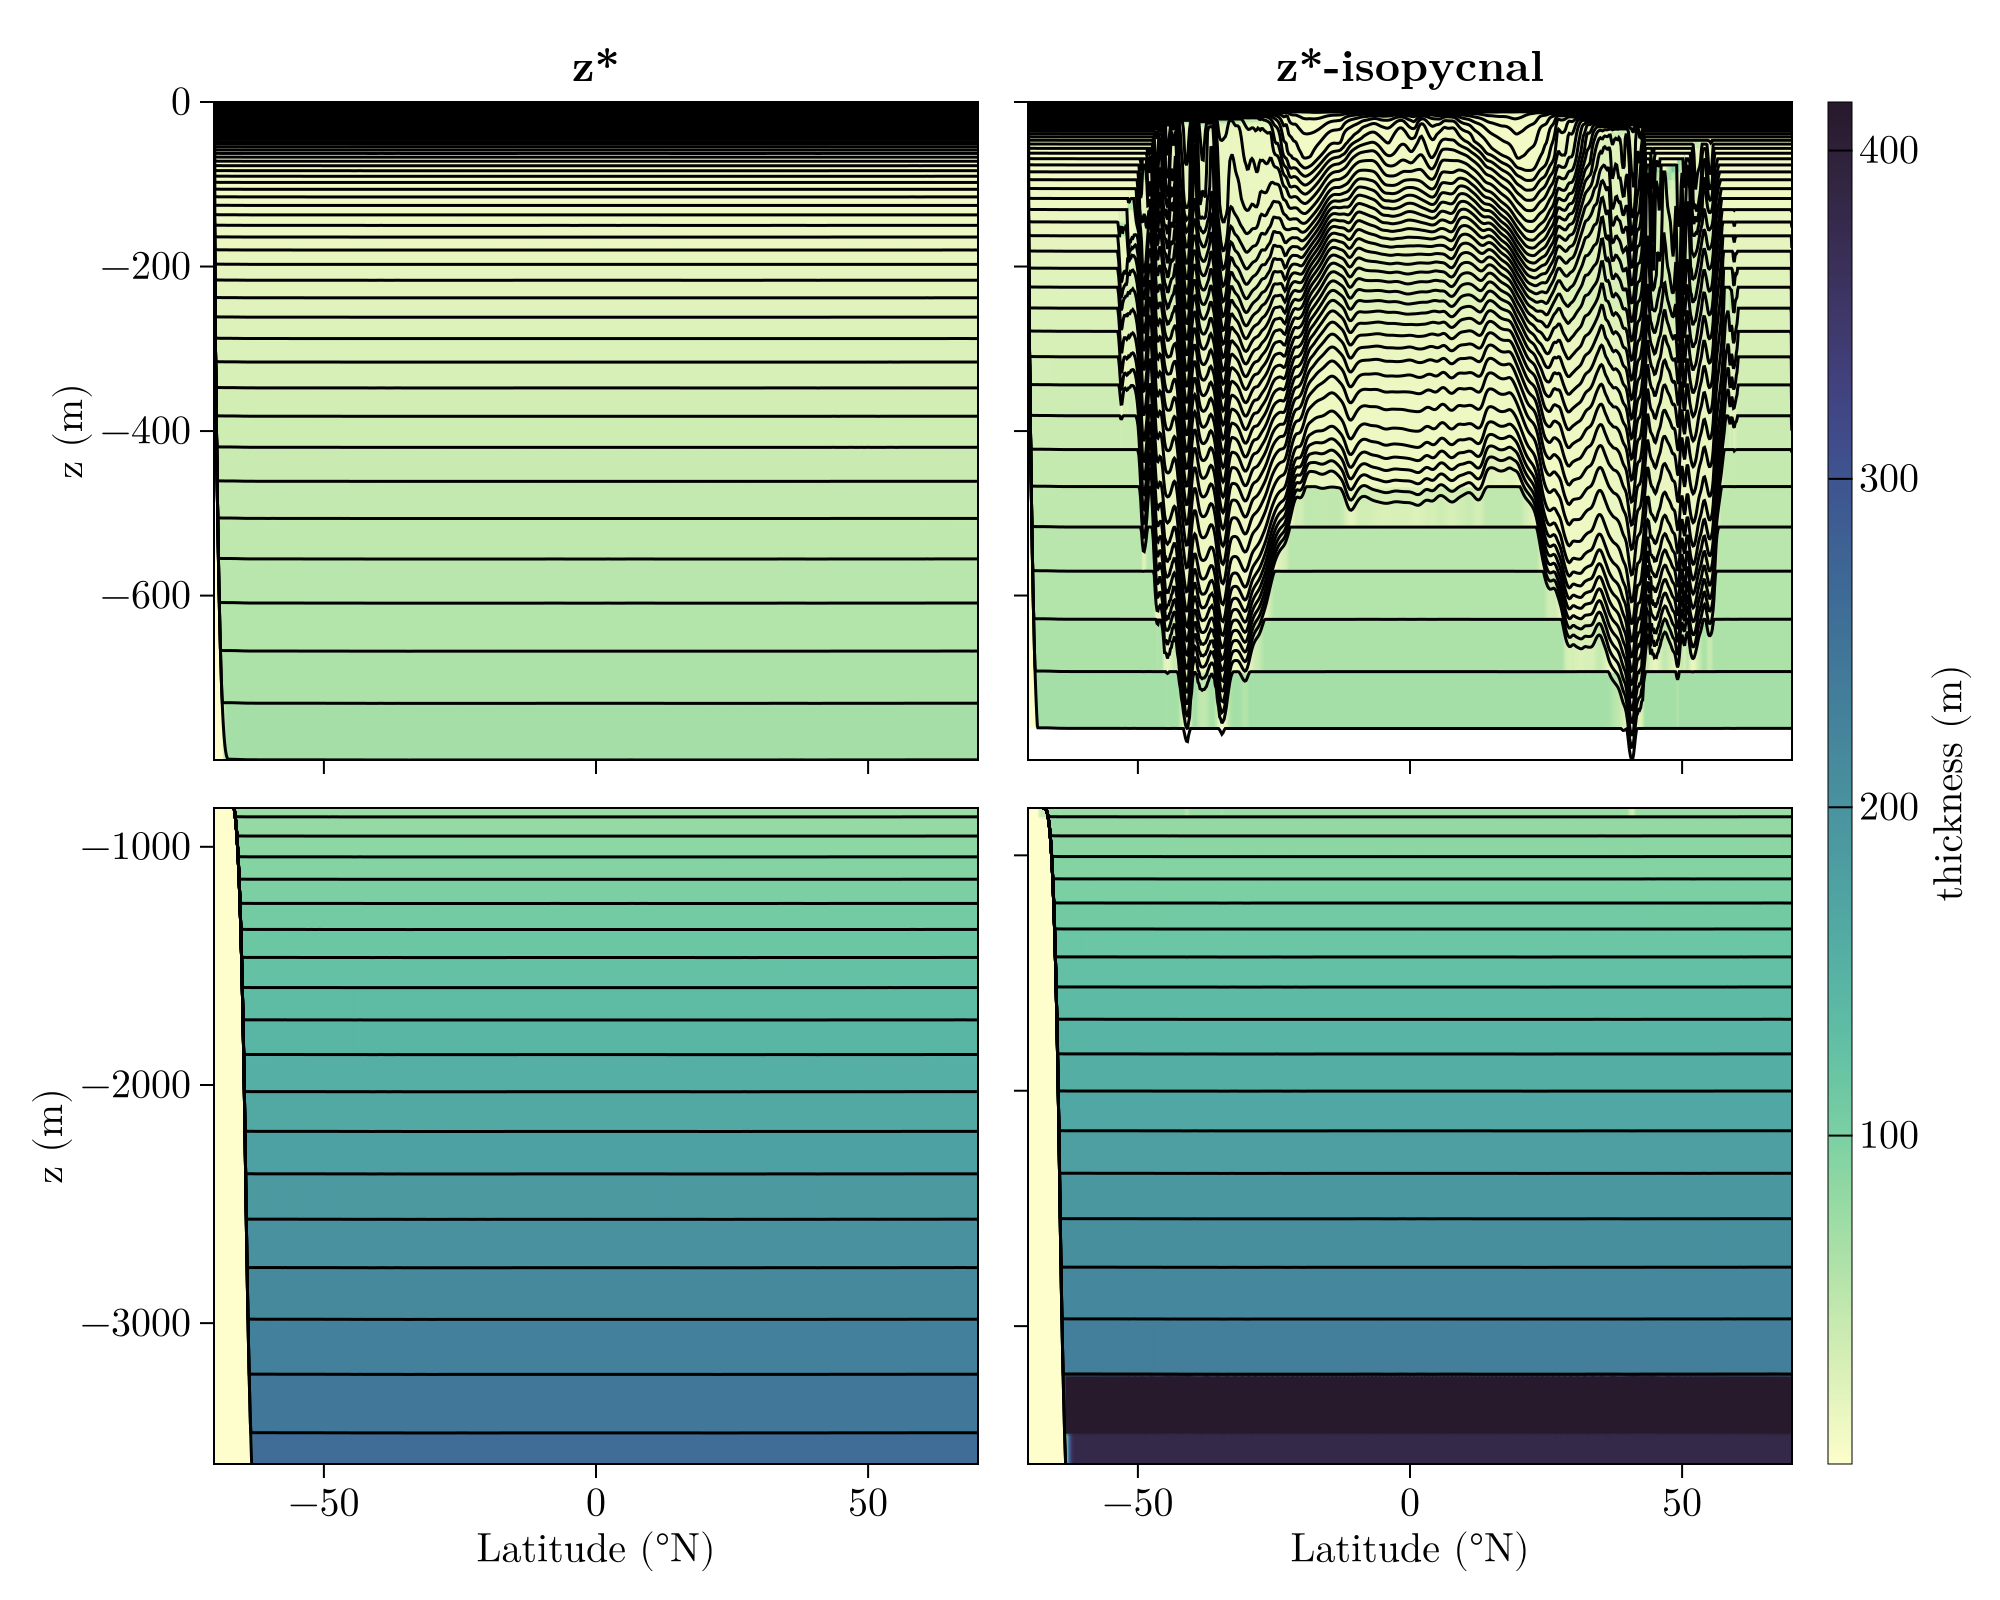

In [3]:
fig = Figure(size = (1000, 800))

titles = ("z*", "z*-isopycnal")
colorrange = NCDataset(catalogue["hycom-PPMH3"]["monthly"], maskingvalue = NaN) do ds
    h = ds["thkcello"][40, :, :, 1] # middle of domain
    (nanminimum(h), nanmaximum(h))
end

for (j, k) ∈ enumerate(expts)
    
    crs = get_geo_coords(catalogue[k]["static"], catalogue[k]["vc"])
    
    ds = NCDataset(catalogue[k]["monthly"], maskingvalue = NaN)
    h = ds["thkcello"][40, :, :, 1] # middle of domain
    close(ds)

    ∫h = cumsum(h, dims = 2)

    top = 1:55
    bot = top[end]+1:74

    axtop = Axis(fig[1, j], xlabel = "Latitude (°N)", ylabel = "z (m)", title = titles[j])
    hidexdecorations!(axtop, ticks = false)
    hm = heatmap!(axtop, crs.lath, crs.zl[top], h[:, top]; colorrange, colormap = :deep)
    for i ∈ top
        lines!(axtop, crs.lath, -∫h[:, i], color = :black)
    end
    axbot = Axis(fig[2, j], xlabel = "Latitude (°N)", ylabel = "z (m)")
    hm = heatmap!(axbot, crs.lath, crs.zl[bot], h[:, bot]; colorrange, colormap = :deep)
    for i ∈ bot
        lines!(axbot, crs.lath, -∫h[:, i], color = :black)
    end
    ylims!(axbot, crs.zl[bot[end]], crs.zl[bot[1]])
    if  j == 2 
        hideydecorations!(axtop, ticks = false)
        hideydecorations!(axbot, ticks = false)
        Colorbar(fig[1:2, j+1], hm, label = "thickness (m)")
    end

end
rowsize!(fig.layout, 1, Relative(1/2))
fig

## Comparison to what is seen in ANU-TUB repo

Initially when looking at the vertical grid, Jan pointed out there is not too much going on at the boundaries and interior ocean (where there should be).
Andy and Angus have a vertical structure comparison notebook, see [here](https://github.com/AndyHoggANU/anu-tub/blob/master/diagnostics/VerticalStructureComparison.ipynb), where you can see the vertical structure in the deep ocean is much more wiggly (i.e. not following z star).

Below I think I replicate the code they used to generate their figure yet there is still not much going on in the deep ocean.
Their code is looking at a much later date (at least that is what gemini suggested).
The `n` argument selects the last 200 snapshots and the `issel(time=0)` takes the first of these.

Could it be that some of the vertical structure evolves only after the simulation has been run for a long time?
Or perhaps there is something not going quite right with restart?
Might need to ask them if nothing else appears.

In [14]:
ds = NCDataset(catalogue["hycom-PPMH3"]["monthly"], maskingvalue = NaN)
# ds = NCDataset(catalogue["zstar-PPMH3"]["monthly"], maskingvalue = NaN) # check
h = ds["thkcello"][80, :, :, 1]
∫h_test = cumsum(h, dims = 2)
θ = ds["thetao"][80, :, :, 1]
yh = ds["yh"][:]
z = ds["zl"][:]
close(ds)

closed Dataset

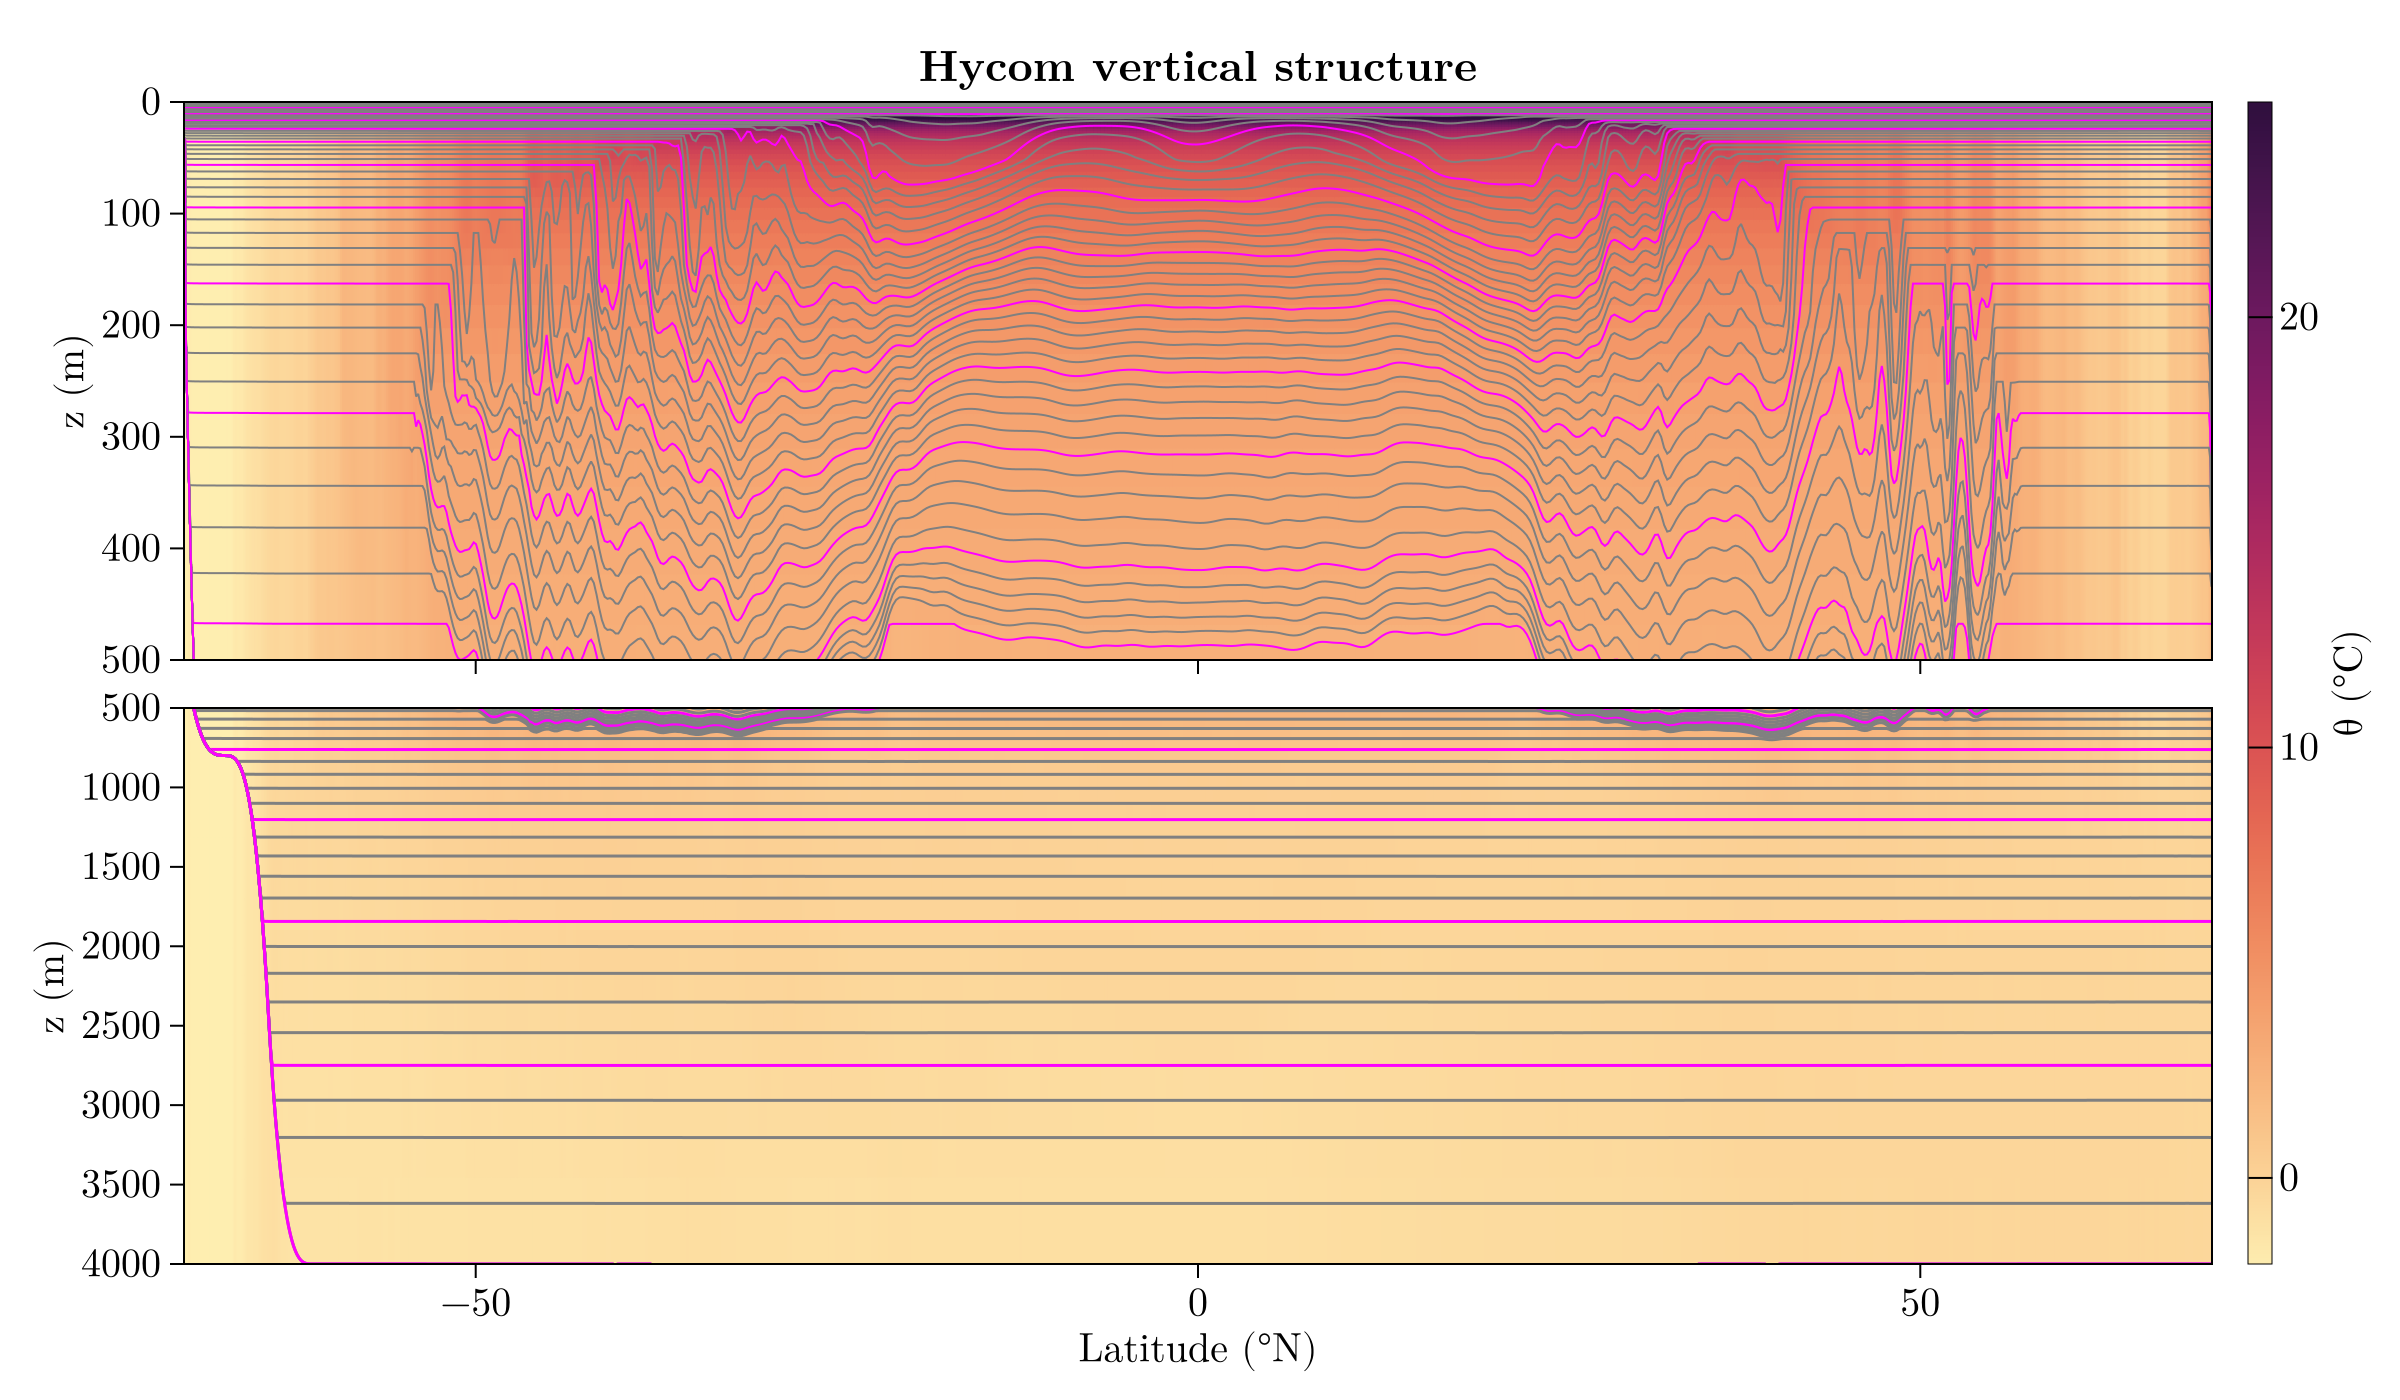

In [16]:
fig = Figure(size = (1200, 700))
colorrange = (-2, 25)
depth_levels = 1:75

axtop = Axis(fig[1, 1], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "Hycom vertical structure")
hidexdecorations!(axtop, ticks = false)
hm = heatmap!(axtop, yh, z, θ; colorrange, colormap = :matter)
for i ∈ depth_levels
    if i % 5 == 0
        lines!(axtop, yh, ∫h_test[:, i], color = :magenta, linewidth = 1)
    else
        lines!(axtop, yh, ∫h_test[:, i], color = :grey, linewidth = 1)
    end
end
ylims!(axtop, 0, 500)
axtop.yreversed = true

axbot = Axis(fig[2, 1], xlabel = "Latitude (°N)", ylabel = "z (m)", yreversed = true)
hm = heatmap!(axbot, yh, z, θ; colorrange, colormap = :matter)
for i ∈ depth_levels
    if i % 5 == 0
        lines!(axbot, yh, ∫h_test[:, i], color = :magenta)
    else
        lines!(axbot, yh, ∫h_test[:, i], color = :grey)
    end
end
ylims!(axbot, 500, 4000)
axbot.yreversed = true

Colorbar(fig[1:2, 2], hm, label = "θ (°C)")

fig

In [21]:
save("theta_hycom_grid_initial.png", fig)

## Comparison to some output from Andy Hogg

In [2]:
Hogg_run = "/g/data/x77/amh157/anu-tub/outputs/anu-tub-hycom1-500/output342/ocean_month.nc"

"/g/data/x77/amh157/anu-tub/outputs/anu-tub-hycom1-500/output342/ocean_month.nc"

In [17]:
ds = NCDataset(Hogg_run)
h = ds["thkcello"][80, :, :, 1]
∫h_test = cumsum(h, dims = 2)
θ = ds["thetao"][80, :, :, 1]
yh = ds["yh"][:]
z = ds["zl"][:]
close(ds)

closed Dataset

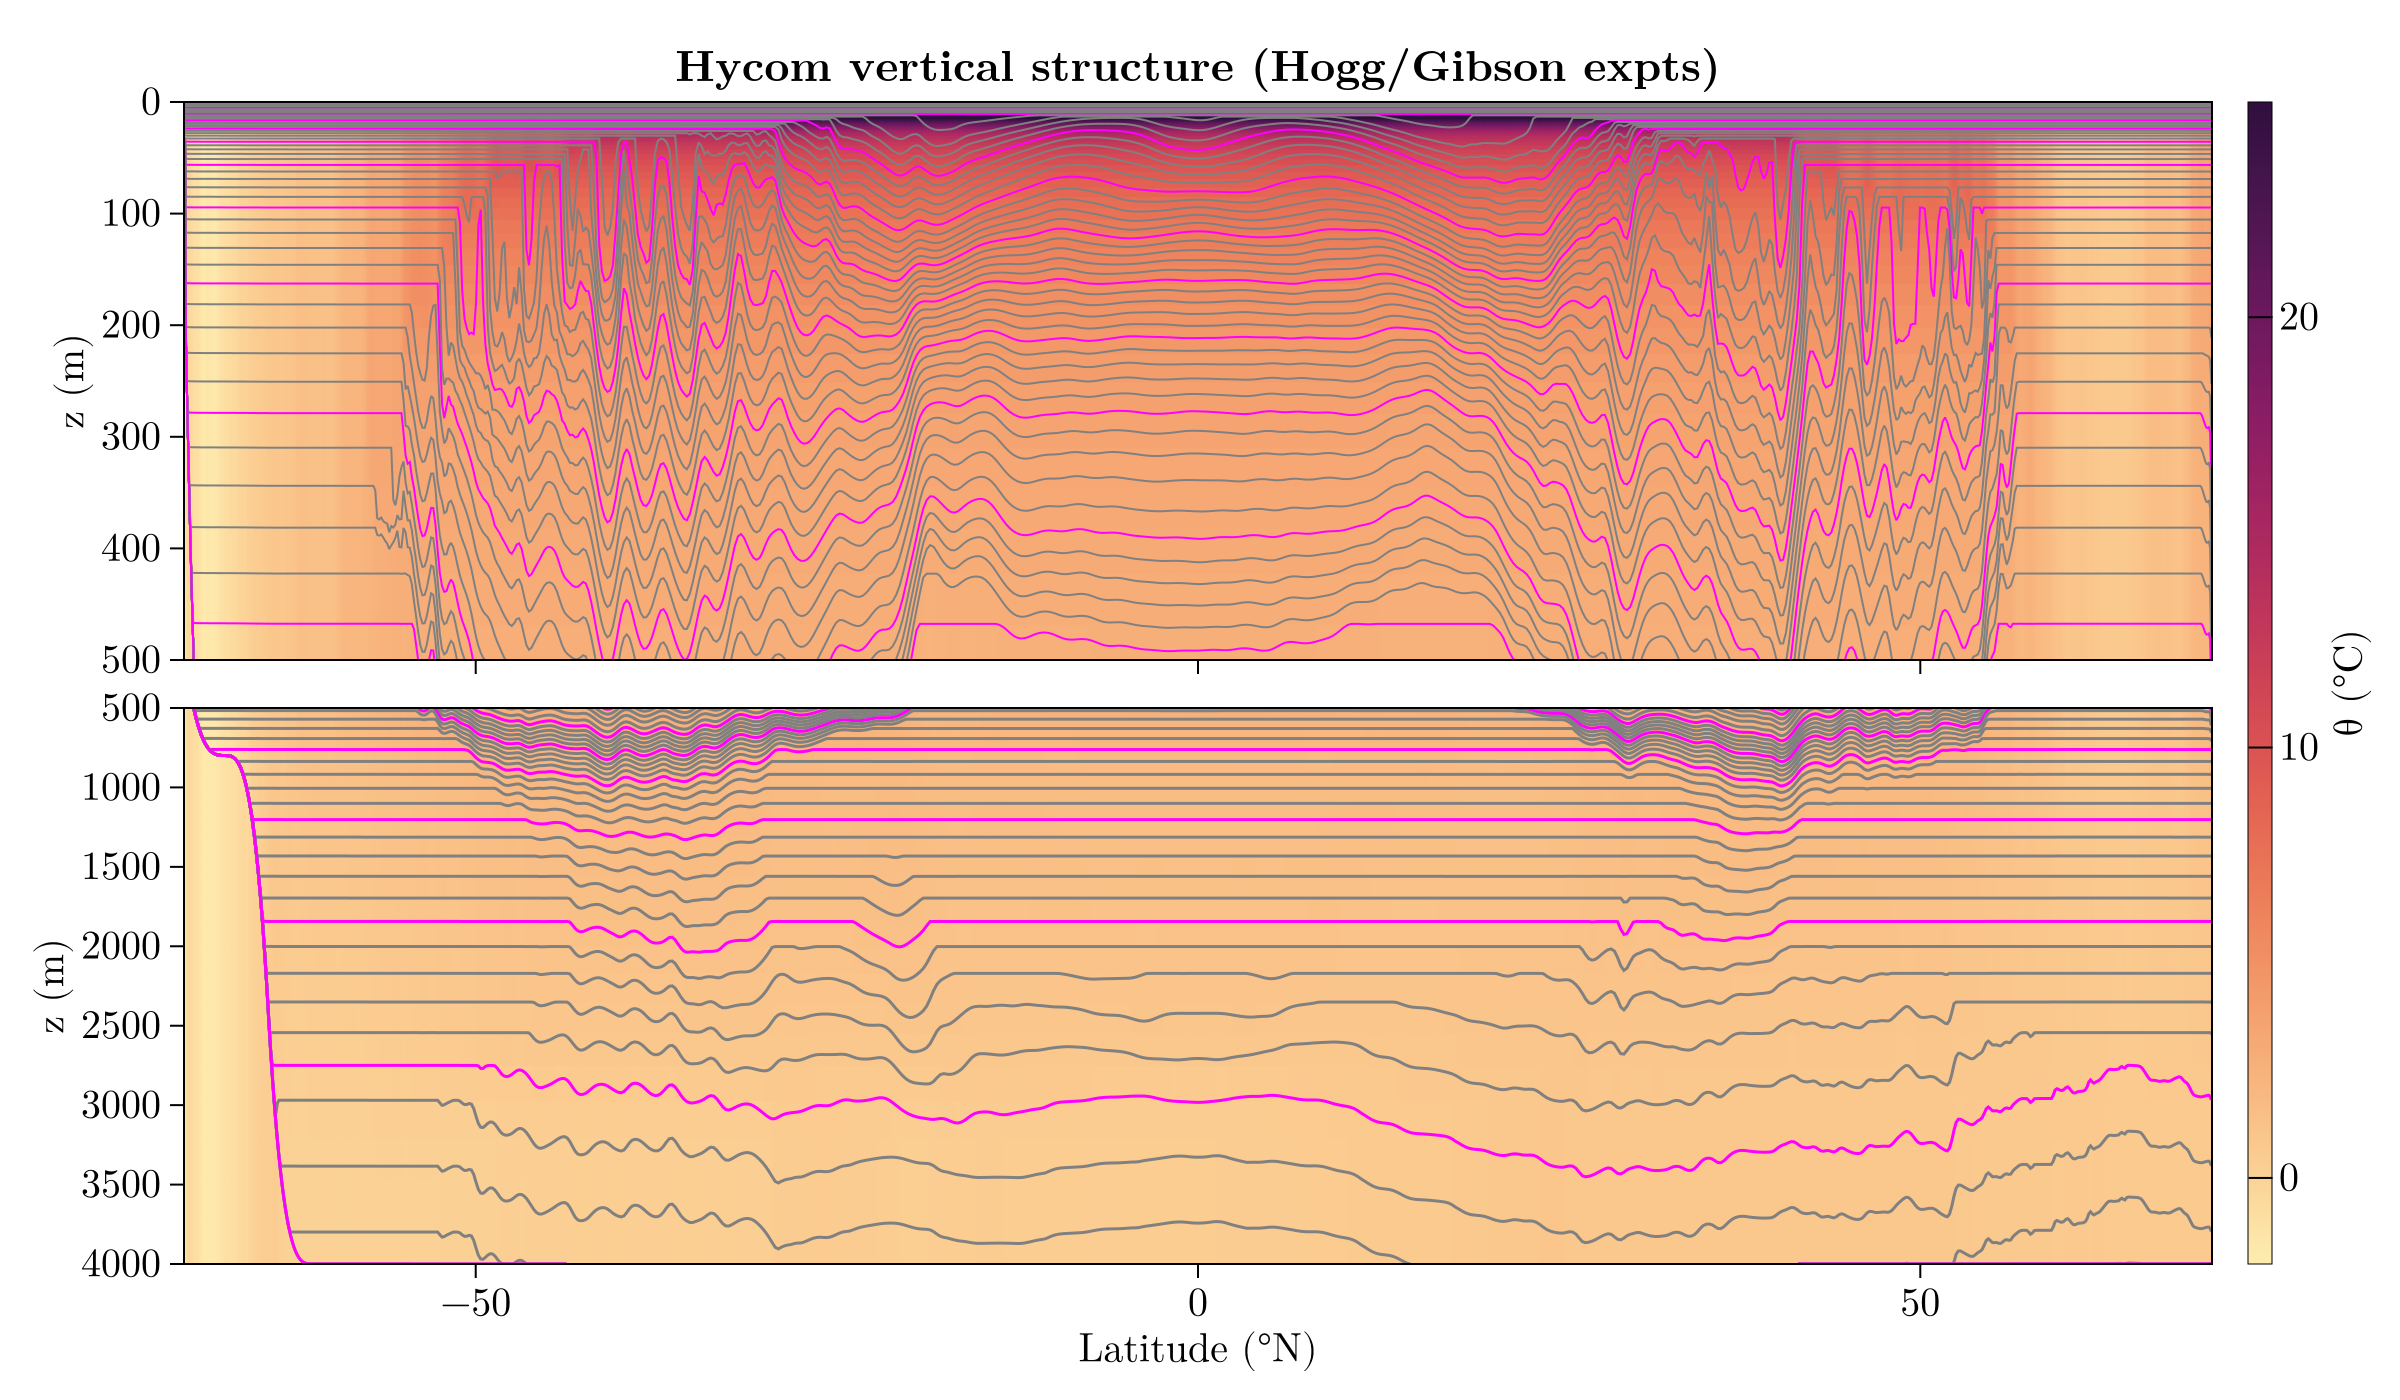

In [21]:
fig = Figure(size = (1200, 700))
colorrange = (-2, 25)
depth_levels = 1:75

axtop = Axis(fig[1, 1], xlabel = "Latitude (°N)", ylabel = "z (m)", title = "Hycom vertical structure (Hogg/Gibson expts)")
hidexdecorations!(axtop, ticks = false)
hm = heatmap!(axtop, yh, z, θ; colorrange, colormap = :matter)
for i ∈ depth_levels
    if i % 5 == 0
        lines!(axtop, yh, ∫h_test[:, i], color = :magenta, linewidth = 1)
    else
        lines!(axtop, yh, ∫h_test[:, i], color = :grey, linewidth = 1)
    end
end
ylims!(axtop, 0, 500)
axtop.yreversed = true

axbot = Axis(fig[2, 1], xlabel = "Latitude (°N)", ylabel = "z (m)", yreversed = true)
hm = heatmap!(axbot, yh, z, θ; colorrange, colormap = :matter)
for i ∈ depth_levels
    if i % 5 == 0
        lines!(axbot, yh, ∫h_test[:, i], color = :magenta)
    else
        lines!(axbot, yh, ∫h_test[:, i], color = :grey)
    end
end
ylims!(axbot, 500, 4000)
axbot.yreversed = true

Colorbar(fig[1:2, 2], hm, label = "θ (°C)")

fig

In [22]:
save("theta_hycom_grid_Hogg.png", fig)